# AI-Driven Regulatory Genomics Analysis of Lung Cancer

## Overview
This project integrates ATAC-seq and microarray data to investigate how chromatin accessibility relates to gene expression in A549 lung cancer cells.

## Objective
To engineer gene-level regulatory features from ATAC-seq peaks and evaluate whether chromatin accessibility can predict gene expression state using an interpretable machine learning model.

## Key findings
- Promoter accessibility shows stronger association with gene expression than distal accessibility
- A Random Forest classifier predicts high- vs low-expression genes with ROC-AUC ≈ 0.73
- Promoter features dominate predictive importance

## 1.Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [52]:
import os

base = "/content/drive/MyDrive/lung_ai_project"

folders = [
    "data/atac",
    "data/microarray",
    "data/annotation",
    "results"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)


## 2. Data Acquisition

In [3]:
!wget -c -O /content/drive/MyDrive/lung_ai_project/data/atac/GSE114202_RAW.tar \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE114nnn/GSE114202/suppl/GSE114202_RAW.tar"

--2026-04-20 17:39:29--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE114nnn/GSE114202/suppl/GSE114202_RAW.tar
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [53]:
import tarfile

tar_path = "/content/drive/MyDrive/lung_ai_project/data/atac/GSE114202_RAW.tar"
extract_path = "/content/drive/MyDrive/lung_ai_project/data/atac/extracted"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path) as tar:
    tar.extractall(extract_path)


/tmp/ipykernel_15387/4190906149.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


In [5]:
import os

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137776_ENCFF631HEX_signal_of_unique_reads_GRCh38.bigWig
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137777_ENCFF103COS_signal_of_unique_reads_GRCh38.bigWig
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137778_ENCFF957GCK_signal_of_unique_reads_GRCh38.bigWig
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137776_ENCFF550DRF_peaks_GRCh38.bed.gz
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137776_ENCLB522HCS_README.txt.gz
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137776_ENCFF801MPJ_peaks_GRCh38.bigBed
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137777_ENCFF348ZZP_peaks_GRCh38.bed.gz
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137777_ENCLB768JUJ_README.txt.gz
/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137778_ENCFF070PUA_peaks_GRCh38.bigBed
/content/drive/MyDrive/lung_ai_project/data

In [6]:
!wget -O /content/drive/MyDrive/lung_ai_project/data/microarray/GSE17708_series_matrix.txt.gz \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE17nnn/GSE17708/matrix/GSE17708_series_matrix.txt.gz

--2026-04-20 17:40:55--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE17nnn/GSE17708/matrix/GSE17708_series_matrix.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4604333 (4.4M) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/lung_ai_project/data/microarray/GSE17708_series_matrix.txt.gz’

/content/drive/MyDr 100%[===================>]   4.39M  2.86MB/s    in 1.5s    

2026-04-20 17:40:58 (2.86 MB/s) - ‘/content/drive/MyDrive/lung_ai_project/data/microarray/GSE17708_series_matrix.txt.gz’ saved [4604333/4604333]



In [7]:
from google.colab import files
uploaded = files.upload()

Saving GPL570-55999.txt to GPL570-55999 (1).txt


In [9]:
import shutil

shutil.move(
    "GPL570-55999 (1).txt",
    "/content/drive/MyDrive/lung_ai_project/data/microarray/GPL570_full_table.txt"
)

'/content/drive/MyDrive/lung_ai_project/data/microarray/GPL570_full_table.txt'

## 3. Microarray Annotation Processing

In [10]:
path = "/content/drive/MyDrive/lung_ai_project/data/microarray/GPL570_full_table.txt"

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(30):
        print(f"{i+1}: {f.readline().rstrip()}")

1: #ID = Affymetrix Probe Set ID
2: #GB_ACC = GenBank Accession Number
3: #SPOT_ID = identifies controls
4: #Species Scientific Name = The genus and species of the organism represented by the probe set.
5: #Annotation Date = The date that the annotations for this probe array were last updated. It will generally be earlier than the date when the annotations were posted on the Affymetrix web site.
6: #Sequence Type =
7: #Sequence Source = The database from which the sequence used to design this probe set was taken.
8: #Target Description =
9: #Representative Public ID = The accession number of a representative sequence. Note that for consensus-based probe sets, the representative sequence is only one of several sequences (sequence sub-clusters) used to build the consensus sequence and it is not directly used to derive the probe sequences. The representative sequence is chosen during array design as a sequence that is best associated with the transcribed region being interrogated by the p

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/lung_ai_project/data/microarray/GPL570_full_table.txt"

gpl = pd.read_csv(
    path,
    sep="\t",
    skiprows=16,   # ← correct (skip metadata)
    low_memory=False
)

print("Shape:", gpl.shape)
print(gpl.columns.tolist())
gpl.head()

In [12]:
probe_map = gpl[["ID", "Gene Symbol"]].copy()

probe_map.columns = ["probe_id", "gene_symbol"]

# Clean
probe_map["gene_symbol"] = (
    probe_map["gene_symbol"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove invalid
probe_map = probe_map[
    (probe_map["gene_symbol"].notna()) &
    (probe_map["gene_symbol"] != "---")
]

In [ ]:
probe_map["gene_symbol"] = probe_map["gene_symbol"].str.split(" /// ")
probe_map = probe_map.explode("gene_symbol")
probe_map["gene_symbol"] = probe_map["gene_symbol"].str.strip()

probe_map.head()

## 4. Microarray Expression Processing

In [57]:
from io import StringIO
import gzip
import pandas as pd

matrix_path = "/content/drive/MyDrive/lung_ai_project/data/microarray/GSE17708_series_matrix.txt.gz"

table_lines = []
inside_table = False

with gzip.open(matrix_path, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("!series_matrix_table_begin"):
            inside_table = True
            continue
        if line.startswith("!series_matrix_table_end"):
            break
        if inside_table:
            table_lines.append(line)

expr_raw = pd.read_csv(
    StringIO("".join(table_lines)),
    sep="\t",
    engine="python"
)

print( expr_raw.shape)

(54675, 27)


In [15]:
expr_raw.columns = [c.replace('"', '').strip() for c in expr_raw.columns]

print(expr_raw.columns.tolist())
expr_raw.head()

['ID_REF', 'GSM442026', 'GSM442027', 'GSM442028', 'GSM442029', 'GSM442030', 'GSM442031', 'GSM442032', 'GSM442033', 'GSM442034', 'GSM442035', 'GSM442036', 'GSM442037', 'GSM442038', 'GSM442039', 'GSM442040', 'GSM442041', 'GSM442042', 'GSM442043', 'GSM442044', 'GSM442045', 'GSM442046', 'GSM442047', 'GSM442048', 'GSM442049', 'GSM442050', 'GSM442051']


,ID_REF,GSM442026,GSM442027,GSM442028,GSM442029,GSM442030,GSM442031,GSM442032,GSM442033,GSM442034,...,GSM442042,GSM442043,GSM442044,GSM442045,GSM442046,GSM442047,GSM442048,GSM442049,GSM442050,GSM442051
0,1007_s_at,3.728354,3.775465,3.742647,3.824386,3.783618,3.895920,3.836261,3.827499,3.928805,...,4.125774,4.089128,4.098782,4.138934,4.090822,4.036789,4.111061,4.074926,4.082103,4.105067
1,1053_at,3.298853,2.849419,3.077004,3.081347,3.056524,2.850033,3.047664,3.031408,2.931966,...,2.830589,2.804821,2.743510,2.788168,2.831230,2.982271,2.885926,2.929930,2.902547,2.845098
2,117_at,2.346353,2.315970,2.198657,2.170262,2.152288,2.181844,2.276462,2.204120,2.033424,...,2.198657,2.409933,1.924279,2.252853,2.214844,2.235528,2.238046,2.371068,2.418301,2.326336
3,121_at,3.084934,3.200850,3.019947,3.101403,3.154424,3.098990,3.090611,3.143327,3.024075,...,3.031408,3.078819,3.046885,2.974051,2.998695,3.018700,3.119256,3.090611,3.112940,3.053846
4,1255_g_at,2.285557,2.117271,2.269513,2.307496,2.287802,2.243038,2.225309,2.301030,2.117271,...,2.161368,2.225309,2.195900,2.187521,2.225309,2.093422,2.271842,2.274158,2.243038,2.255273


In [16]:
import gzip

with gzip.open(matrix_path, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            print(line)
        if line.startswith("!Sample_geo_accession"):
            print(line)

!Sample_title	"A549 lung adenocarcinoma cell line, untreated, experiment #1"	"A549 lung adenocarcinoma cell line, untreated, experiment #2"	"A549 lung adenocarcinoma cell line, untreated, experiment #3"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 0.5 h, experiment #1"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 0.5 h, experiment #2"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 0.5 h, experiment #3"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 1 h, experiment #1"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 1 h, experiment #2"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 1 h, experiment #3"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 2 h, experiment #1"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 2 h, experiment #2"	"A549 lung adenocarcinoma cell line treated with TGFB1 protein for 4 h, experiment #1"	"A549 lu

In [ ]:
probe_expr = expr_raw[["ID_REF", "GSM442026", "GSM442027", "GSM442028"]].copy()
probe_expr.columns = ["probe_id", "rep1", "rep2", "rep3"]

for c in ["rep1", "rep2", "rep3"]:
    probe_expr[c] = pd.to_numeric(probe_expr[c], errors="coerce")

probe_expr["mean_expression"] = probe_expr[["rep1", "rep2", "rep3"]].mean(axis=1)

print("Probe rows:", len(probe_expr))
probe_expr.head()

In [ ]:
expr_annot = pd.merge(probe_expr, probe_map, on="probe_id", how="inner")

print("Merged probe-expression rows:", len(expr_annot))
expr_annot.head()

  ##  5. Gene-Level Expression Aggregation

In [ ]:
gene_expr = (
    expr_annot.groupby("gene_symbol", as_index=False)["mean_expression"]
    .median()
)

gene_expr.columns = ["gene", "mean_expression"]

print("Gene-level rows:", len(gene_expr))
gene_expr.head()

In [20]:
gene_expr.to_csv(
    "/content/drive/MyDrive/lung_ai_project/results/gene_expression_from_microarray.csv",
    index=False
)

print("Saved gene-level expression table.")

Saved gene-level expression table.


In [21]:
print("Unique genes:", gene_expr["gene"].nunique())
print(gene_expr["mean_expression"].describe())

Unique genes: 24441
count    24441.000000
mean         2.581335
std          0.530312
min          1.698970
25%          2.181754
50%          2.417338
75%          2.887842
max          4.606805
Name: mean_expression, dtype: float64


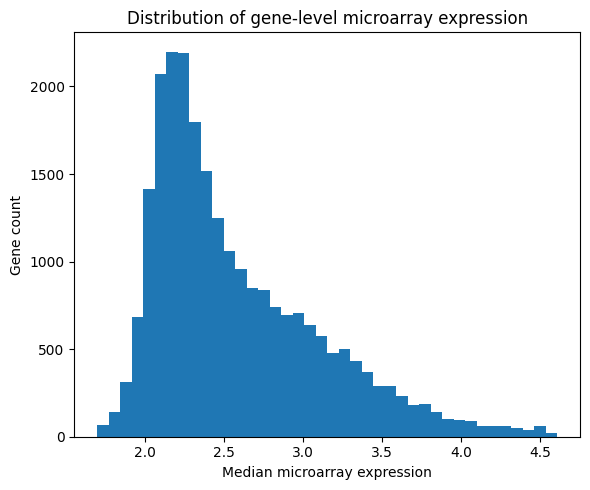

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.hist(gene_expr["mean_expression"].dropna(), bins=40)
plt.xlabel("Median microarray expression")
plt.ylabel("Gene count")
plt.title("Distribution of gene-level microarray expression")
plt.tight_layout()
plt.show()

## The distribution of median gene-level microarray expression is right-skewed, which is consistent with typical transcript abundance profiles.

## 6. Expression Data Cleaning

In [23]:
gene_expr = gene_expr[
    (gene_expr["gene"].str.len() < 15) &   # remove weird long names
    (~gene_expr["gene"].str.contains("LOC|MIR", na=False))
]

print("Filtered genes:", len(gene_expr))

Filtered genes: 22124


## 7. ATAC-seq Feature Engineering

In [24]:
!pip install pyranges

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.7 MB/s eta 0:00:00
  Created wheel for sorted_nearest: filename=sorted_nearest-0.0.41-cp312-cp312-linux_x86_64.whl size=6699065 sha256=78811199b0b454ccf35810f6c0bcbe8d6cd171df3c9f5b6a22f1d5258ca49e70
  Stored in directory: /root/.cache/pip/wheels/7c/cb/a4/a6f831a60e479b9001be190e91000cc472addeab871957e5a9
Successfully built sorted_nearest


In [25]:
!wget -O /content/drive/MyDrive/lung_ai_project/data/annotation/gencode.v44.annotation.gtf.gz \
https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.annotation.gtf.gz

--2026-04-20 17:53:00--  https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.annotation.gtf.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49721965 (47M) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/lung_ai_project/data/annotation/gencode.v44.annotation.gtf.gz’

/content/drive/MyDr 100%[===================>]  47.42M  11.9MB/s    in 5.0s    

2026-04-20 17:53:06 (9.47 MB/s) - ‘/content/drive/MyDrive/lung_ai_project/data/annotation/gencode.v44.annotation.gtf.gz’ saved [49721965/49721965]



In [26]:
import pyranges as pr

GTF_FILE = "/content/drive/MyDrive/lung_ai_project/data/annotation/gencode.v44.annotation.gtf.gz"

gtf = pr.read_gtf(GTF_FILE)
print(gtf)

+--------------+------------+------------+-----------+-----------+-------+
| Chromosome   | Source     | Feature    | Start     | End       | +21   |
| (category)   | (object)   | (object)   | (int64)   | (int64)   | ...   |
|--------------+------------+------------+-----------+-----------+-------|
| chr1         | HAVANA     | gene       | 11868     | 14409     | ...   |
| chr1         | HAVANA     | transcript | 11868     | 14409     | ...   |
| chr1         | HAVANA     | exon       | 11868     | 12227     | ...   |
| chr1         | HAVANA     | exon       | 12612     | 12721     | ...   |
| ...          | ...        | ...        | ...       | ...       | ...   |
| chrY         | HAVANA     | exon       | 57213879  | 57213964  | ...   |
| chrY         | HAVANA     | exon       | 57213525  | 57213602  | ...   |
| chrY         | HAVANA     | exon       | 57213203  | 57213357  | ...   |
| chrY         | HAVANA     | exon       | 57212183  | 57213125  | ...   |
+--------------+---------

In [ ]:
import numpy as np

genes = gtf[gtf.Feature == "gene"].df.copy()
genes = genes[genes["gene_type"] == "protein_coding"].copy()

genes["gene_name"] = genes["gene_name"].str.upper()

genes_basic = genes[["Chromosome","Start","End","Strand","gene_name"]].drop_duplicates()

genes_basic["tss"] = np.where(
    genes_basic["Strand"] == "+",
    genes_basic["Start"],
    genes_basic["End"]
)

genes_window = genes_basic.copy()
genes_window["Start"] = (genes_window["Start"] - 50000).clip(lower=0)
genes_window["End"] = genes_window["End"] + 50000

genes_pr = pr.PyRanges(genes_window[["Chromosome","Start","End","gene_name"]])

print("Genes:", len(genes_window))
genes_window.head()

In [ ]:
PEAK_FILE = "/content/drive/MyDrive/lung_ai_project/data/atac/extracted/GSM3137776_ENCFF550DRF_peaks_GRCh38.bed.gz"

peaks = pr.read_bed(PEAK_FILE)
peak_df = peaks.df.copy()

if "Score" not in peak_df.columns:
    peak_df["Score"] = 1

peak_df["peak_length"] = peak_df["End"] - peak_df["Start"]

peaks_pr = pr.PyRanges(peak_df)

print("Peaks:", len(peak_df))
peak_df.head()

## We map ATAC-seq peaks to nearby genes using a ±50 kb window to approximate potential cis-regulatory interactions.

## 8. Multi-omics Integration (ATAC + Expression)

In [ ]:
features = df.groupby("gene_name").agg(
    peak_count=("Start", "size"),
    total_signal=("Score", "sum"),
    mean_signal=("Score", "mean"),
    max_signal=("Score", "max"),
    mean_peak_length=("peak_length", "mean")
).reset_index()

features = features.rename(columns={"gene_name": "gene"})
features["gene"] = features["gene"].astype(str).str.upper()

print("ATAC genes:", len(features))
features.head()

In [ ]:
gene_expr["gene"] = gene_expr["gene"].astype(str).str.upper().str.strip()

gene_expr = gene_expr[
    (gene_expr["gene"] != "---") &
    (~gene_expr["gene"].str.contains("///", na=False))
].copy()

print("Clean expression genes:", len(gene_expr))
gene_expr.head()

##Initial correlation between total nearby accessibility and expression was weak, motivating more biologically informed feature engineering.

In [ ]:
merged = pd.merge(features, gene_expr, on="gene", how="inner").dropna().copy()

print("Merged genes:", len(merged))
merged.head()

In [33]:
from scipy.stats import pearsonr

corr, pval = pearsonr(merged["peak_count"], merged["mean_expression"])
print("Pearson correlation:", corr)
print("P-value:", pval)

Pearson correlation: 0.12056085996412655
P-value: 5.856351483867058e-54


The weak correlation (r ≈ 0.12) suggests that total chromatin accessibility alone is insufficient to explain gene expression, motivating more refined feature engineering.

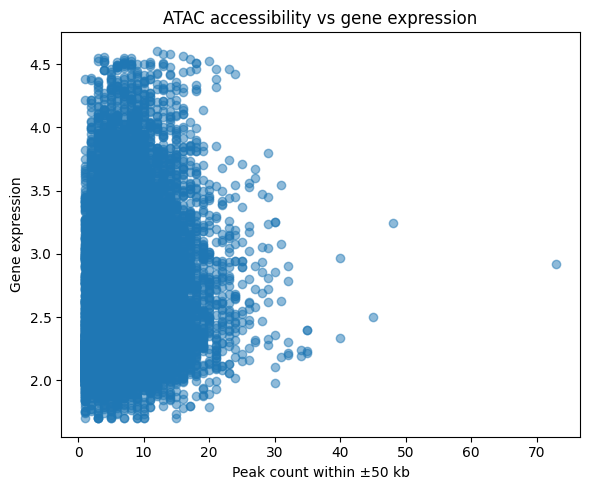

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(merged["peak_count"], merged["mean_expression"], alpha=0.5)
plt.xlabel("Peak count within ±50 kb")
plt.ylabel("Gene expression")
plt.title("ATAC accessibility vs gene expression")
plt.tight_layout()
plt.show()

In [40]:
genes_pr = pr.PyRanges(
    genes_window[["Chromosome", "Start", "End", "gene_name", "tss"]]
)

overlap = peaks_pr.join(genes_pr)
df = overlap.df.copy()

print(df.columns.tolist())
df.head()

['Chromosome', 'Start', 'End', 'Name', 'Score', 'Strand', 'ThickStart', 'ThickEnd', 'ItemRGB', 'BlockCount', 'peak_length', 'Start_b', 'End_b', 'gene_name', 'tss']


,Chromosome,Start,End,Name,Score,Strand,ThickStart,ThickEnd,ItemRGB,BlockCount,peak_length,Start_b,End_b,gene_name,tss
0,chr1,904303,904912,atacseq_170613.t0_rep1.dedup.masked.sorted_pea...,230,.,6.91177,25.99470,23.06584,453,609,873922,994575,SAMD11,923922
1,chr1,904303,904912,atacseq_170613.t0_rep1.dedup.masked.sorted_pea...,230,.,6.91177,25.99470,23.06584,453,609,894202,1009309,NOC2L,959309
2,chr1,906783,907010,atacseq_170613.t0_rep1.dedup.masked.sorted_pea...,48,.,3.08057,7.03799,4.80576,168,227,873922,994575,SAMD11,923922
3,chr1,906783,907010,atacseq_170613.t0_rep1.dedup.masked.sorted_pea...,48,.,3.08057,7.03799,4.80576,168,227,894202,1009309,NOC2L,959309
4,chr1,911200,911493,atacseq_170613.t0_rep1.dedup.masked.sorted_pea...,92,.,4.03423,11.70265,9.25857,130,293,873922,994575,SAMD11,923922


## 9. Promoter vs Distal Regulatory Analysis

In [61]:
df["peak_center"] = (df["Start"] + df["End"]) / 2
df["distance"] = abs(df["peak_center"] - df["tss"])
df["region"] = np.where(df["distance"] <= 2000, "promoter", "distal")

features_split = df.groupby(["gene_name", "region"]).agg(
    peak_count=("Start", "size"),
    total_signal=("Score", "sum")
).reset_index()

## To improve interpretability, ATAC peaks were separated into promoter-proximal and distal categories using distance to transcription start site (TSS). This allows testing whether promoter accessibility is more directly associated with expression than distal accessibility.

In [62]:
features_split = df.groupby(["gene_name", "region"]).agg(
    peak_count=("Start", "size"),
    total_signal=("Score", "sum")
).reset_index()

features_split = features_split.pivot(
    index="gene_name",
    columns="region",
    values="peak_count"
).fillna(0)

# ensure both exist
for col in ["promoter", "distal"]:
    if col not in features_split.columns:
        features_split[col] = 0

features_split = features_split[["distal", "promoter"]]
features_split.columns = ["distal_peaks", "promoter_peaks"]

features_split = features_split.reset_index().rename(columns={"gene_name": "gene"})

In [63]:
print(features_split["promoter_peaks"].describe())
print(features_split["distal_peaks"].describe())

count    19044.000000
mean         0.914304
std          0.728492
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: promoter_peaks, dtype: float64
count    19044.000000
mean         6.446387
std          4.447611
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max         73.000000
Name: distal_peaks, dtype: float64


## Promoter accessibility showed a stronger association with gene expression than distal accessibility, suggesting that proximal chromatin accessibility captures more direct transcriptional regulation in this dataset.

In [64]:
merged2 = pd.merge(features_split, gene_expr, on="gene", how="inner")

print("Merged genes:", len(merged2))

Merged genes: 16340


In [65]:
from scipy.stats import pearsonr

print("Promoter:", pearsonr(merged2["promoter_peaks"], merged2["mean_expression"]))
print("Distal:", pearsonr(merged2["distal_peaks"], merged2["mean_expression"]))

Promoter: PearsonRResult(statistic=np.float64(0.26791199171688), pvalue=np.float64(1.3166623043601092e-266))
Distal: PearsonRResult(statistic=np.float64(0.08067492221599618), pvalue=np.float64(5.23384348609592e-25))


Separating promoter and distal accessibility revealed that promoter-proximal chromatin accessibility shows a stronger association with gene expression than distal regions

## 10. Machine Learning Model

In [66]:
model_df = merged2.copy()

q25 = model_df["mean_expression"].quantile(0.25)
q75 = model_df["mean_expression"].quantile(0.75)

model_df["label"] = np.nan
model_df.loc[model_df["mean_expression"] <= q25, "label"] = 0
model_df.loc[model_df["mean_expression"] >= q75, "label"] = 1

model_df = model_df.dropna(subset=["label"]).copy()
model_df["label"] = model_df["label"].astype(int)

In [67]:
import numpy as np

model_df["log_promoter"] = np.log1p(model_df["promoter_peaks"])
model_df["log_distal"] = np.log1p(model_df["distal_peaks"])

## 11. Results and Interpretation

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

X = model_df[[
    "promoter_peaks",
    "distal_peaks",
    "log_promoter",
    "log_distal"
]]

y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7203182374541004
ROC-AUC: 0.747968131310029


## The Random Forest model achieved moderate predictive performance (ROC-AUC ≈ 0.74), indicating that accessibility-derived regulatory features contain meaningful information about expression state.

## Feature importance analysis showed that promoter accessibility features were substantially more informative than distal features, supporting the stronger promoter-expression association observed in correlation analysis.

In [69]:
importance = pd.DataFrame({
    "feature": ["promoter_peaks", "distal_peaks", "log_promoter", "log_distal"],
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print(importance)

          feature  importance
0  promoter_peaks    0.446833
2    log_promoter    0.415951
1    distal_peaks    0.068959
3      log_distal    0.068257


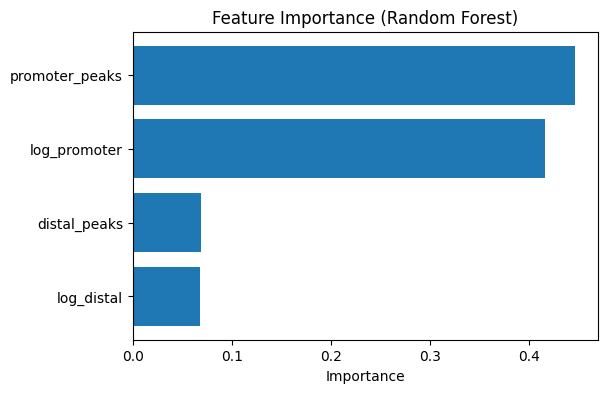

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.barh(importance["feature"], importance["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

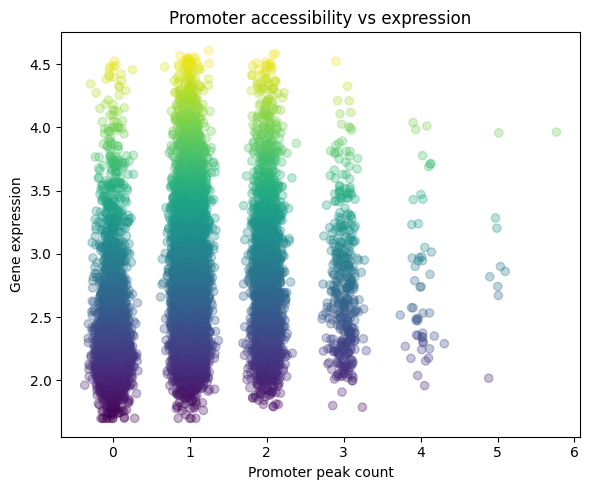

In [71]:
x_jitter = merged2["promoter_peaks"] + np.random.normal(0, 0.1, size=len(merged2))

plt.figure(figsize=(6,5))
plt.scatter(
    x_jitter,
    merged2["mean_expression"],
    c=merged2["mean_expression"],
    alpha=0.3
)
plt.xlabel("Promoter peak count")
plt.ylabel("Gene expression")
plt.title("Promoter accessibility vs expression")
plt.tight_layout()
plt.show()

## 12. Conclusion

In this project, I integrated ATAC-seq and microarray data to explore how chromatin accessibility relates to gene expression in A549 lung cancer cells.

The initial analysis showed that simply counting ATAC peaks within a ±50 kb window has only a weak association with gene expression (r ≈ 0.12). This suggested that a naive proximity-based approach is not sufficient to capture regulatory relationships.

To improve this, I separated accessibility signals into promoter-proximal and distal regions based on distance to the transcription start site. This made a clear difference: promoter accessibility showed a noticeably stronger association with gene expression (r ≈ 0.24–0.27), while distal accessibility remained weak (r ≈ 0.08). This indicates that promoter regions carry more direct regulatory signal in this dataset.

I then used these features in a Random Forest model to predict high vs low expression genes. The model achieved moderate performance (ROC-AUC ≈ 0.74), showing that chromatin accessibility does contain predictive information, although it is not sufficient on its own for highly accurate prediction.

Feature importance analysis further reinforced this observation — promoter-related features consistently contributed more than distal ones. This aligns with biological expectations, where promoter accessibility is closely tied to transcription initiation, while distal elements act in a more context-dependent manner.

There are some limitations to this approach. The ±50 kb window is a simplified assumption and does not capture long-range chromatin interactions. In addition, microarray data has lower resolution compared to RNA-seq, and this analysis is based on a single cell line.

Overall, this project shows that combining biologically informed feature engineering with interpretable machine learning can reveal meaningful patterns in multi-omics data. While the signal is not perfect, the results demonstrate a clear and consistent relationship between promoter accessibility and gene expression.